In [1]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_patient_splits
from models.bu_net import BUNet
from models.prototypical_segmentation import PrototypicalSegmentation
from models.maml_segmentation import MAMLSegmentation
from data.few_shot_sampler import FewShotSampler
from data.augmented_finetune import (
    kshot_augmented_finetune_eval,
    kshot_augmented_prototypical_eval,
    kshot_augmented_maml_eval,
)
from configs.results_utils import save_kshot_results, load_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Build Samplers
train_ids, val_ids, test_ids = get_patient_splits(Config.TRAIN_DATASET_PATH)
 
samplers = {}
for k in Config.K_SHOT_VALUES:
    samplers[k] = FewShotSampler(
        support_ids=val_ids,
        query_ids=test_ids,
        data_path=Config.TRAIN_DATASET_PATH,
        k_shot=k,
        n_query=Config.N_QUERY,
        tumor_only=True,
    )
print("✓ Samplers built")

✓ Splits -> Train: 258, Val: 74, Test: 37
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Samplers built


In [3]:
# CELL 3: Load All Three Models

# --- Baseline ---
baseline_model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(baseline_model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)

# --- Prototypical ---
proto_model = PrototypicalSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

if load_model_weights(proto_model, Config.CHECKPOINT_DIR, 'prototypical_ep1000.pth', Config.DEVICE):
    pass
else:
    print("⚠ Will skip prototypical augmentation")
    proto_model = None

# --- MAML ---
maml_model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

if not load_model_weights(maml_model.model, Config.CHECKPOINT_DIR, 'maml_task1000.pth', Config.DEVICE):
    load_model_weights(maml_model.model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)
    print("⚠ Using baseline weights as MAML fallback")

✓ Loaded checkpoint: best_model.pth
✓ Loaded checkpoint: prototypical_ep1000.pth
✓ Loaded checkpoint: maml_task1000.pth


In [4]:
# CELL 4: Run Augmented Baseline Evaluation 
AUGMENT_FACTOR = 3
N_EPISODES = 50
 
baseline_aug_results = {}
for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"Baseline + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
    print(f"{'='*50}")
 
    dice_scores = kshot_augmented_finetune_eval(
        pretrained_model=baseline_model,
        sampler=samplers[k],
        device=Config.DEVICE,
        lr=1e-4,
        finetune_steps=10,
        n_episodes=N_EPISODES,
        augment_factor=AUGMENT_FACTOR,
    )
 
    baseline_aug_results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
    }
 
# Save
save_kshot_results(baseline_aug_results, Config.RESULTS_DIR, 'baseline_aug_kshot_results.json')


Baseline + Aug: k=1 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7054
  Episode 20/50 | Mean Dice: 0.7202
  Episode 30/50 | Mean Dice: 0.7090
  Episode 40/50 | Mean Dice: 0.7027
  Episode 50/50 | Mean Dice: 0.6924

k=1 (aug 3x) | Mean Dice: 0.6924 ± 0.0921

Baseline + Aug: k=5 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7015
  Episode 20/50 | Mean Dice: 0.7187
  Episode 30/50 | Mean Dice: 0.7377
  Episode 40/50 | Mean Dice: 0.7396
  Episode 50/50 | Mean Dice: 0.7368

k=5 (aug 3x) | Mean Dice: 0.7368 ± 0.0853

Baseline + Aug: k=10 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7626
  Episode 20/50 | Mean Dice: 0.7639
  Episode 30/50 | Mean Dice: 0.7448
  Episode 40/50 | Mean Dice: 0.7460
  Episode 50/50 | Mean Dice: 0.7437

k=10 (aug 3x) | Mean Dice: 0.7437 ± 0.0742

Baseline + Aug: k=20 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7321
  Episode 20/50 | Mean Dice: 0.7435
  Episode 30/50 | Mean Dice: 0.7412
  Episode 40/50 | Mean Dice: 0.7463
  Episode 50/50 | Mean Dice:

In [5]:
# CELL 5: Run Augmented Prototypical Evaluation
proto_aug_results = {}
 
if proto_model is not None:
    for k in Config.K_SHOT_VALUES:
        print(f"\n{'='*50}")
        print(f"Prototypical + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
        print(f"{'='*50}")
 
        dice_scores = kshot_augmented_prototypical_eval(
            proto_model=proto_model,
            sampler=samplers[k],
            device=Config.DEVICE,
            n_episodes=N_EPISODES,
            augment_factor=AUGMENT_FACTOR,
        )
 
        proto_aug_results[k] = {
            'mean': float(np.mean(dice_scores)),
            'std': float(np.std(dice_scores)),
        }
 
    save_kshot_results(proto_aug_results, Config.RESULTS_DIR, 'proto_aug_kshot_results.json')
else:
    print("⚠ Skipping — prototypical model not available")


Prototypical + Aug: k=1 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.8109
  Episode 20/50 | Mean Dice: 0.8075
  Episode 30/50 | Mean Dice: 0.7942
  Episode 40/50 | Mean Dice: 0.7942
  Episode 50/50 | Mean Dice: 0.7923

Proto k=1 (aug 3x) | Mean Dice: 0.7923 ± 0.0534

Prototypical + Aug: k=5 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7846
  Episode 20/50 | Mean Dice: 0.7965
  Episode 30/50 | Mean Dice: 0.7911
  Episode 40/50 | Mean Dice: 0.7931
  Episode 50/50 | Mean Dice: 0.7889

Proto k=5 (aug 3x) | Mean Dice: 0.7889 ± 0.0528

Prototypical + Aug: k=10 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7927
  Episode 20/50 | Mean Dice: 0.7956
  Episode 30/50 | Mean Dice: 0.7976
  Episode 40/50 | Mean Dice: 0.7958
  Episode 50/50 | Mean Dice: 0.7971

Proto k=10 (aug 3x) | Mean Dice: 0.7971 ± 0.0544

Prototypical + Aug: k=20 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7995
  Episode 20/50 | Mean Dice: 0.7960
  Episode 30/50 | Mean Dice: 0.7902
  Episode 40/50 | Mean Dice: 0

In [6]:
# CELL 6: Run Augmented MAML Evaluation
maml_aug_results = {}
 
for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"MAML + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
    print(f"{'='*50}")
 
    dice_scores = kshot_augmented_maml_eval(
        maml_model=maml_model,
        sampler=samplers[k],
        device=Config.DEVICE,
        inner_lr=0.01,
        num_inner_steps=5,
        n_episodes=N_EPISODES,
        augment_factor=AUGMENT_FACTOR,
    )
 
    maml_aug_results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
    }
 
save_kshot_results(maml_aug_results, Config.RESULTS_DIR, 'maml_aug_kshot_results.json')


MAML + Aug: k=1 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7987
  Episode 20/50 | Mean Dice: 0.7779
  Episode 30/50 | Mean Dice: 0.7775
  Episode 40/50 | Mean Dice: 0.7767
  Episode 50/50 | Mean Dice: 0.7782

MAML k=1 (aug 3x) | Mean Dice: 0.7782 ± 0.0557

MAML + Aug: k=5 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.7755
  Episode 20/50 | Mean Dice: 0.7763
  Episode 30/50 | Mean Dice: 0.7824
  Episode 40/50 | Mean Dice: 0.7831
  Episode 50/50 | Mean Dice: 0.7807

MAML k=5 (aug 3x) | Mean Dice: 0.7807 ± 0.0606

MAML + Aug: k=10 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.8182
  Episode 20/50 | Mean Dice: 0.8046
  Episode 30/50 | Mean Dice: 0.8049
  Episode 40/50 | Mean Dice: 0.8099
  Episode 50/50 | Mean Dice: 0.8034

MAML k=10 (aug 3x) | Mean Dice: 0.8034 ± 0.0527

MAML + Aug: k=20 (3x augmentation)
  Episode 10/50 | Mean Dice: 0.8314
  Episode 20/50 | Mean Dice: 0.8055
  Episode 30/50 | Mean Dice: 0.8041
  Episode 40/50 | Mean Dice: 0.8001
  Episode 50/50 | Mean Dice: 

In [7]:
# CELL 7: Load Non-Augmented Results for Comparison
baseline_orig = load_results(Config.RESULTS_DIR, 'baseline_kshot_results.json')
proto_orig = load_results(Config.RESULTS_DIR, 'prototypical_kshot_results.json')
maml_orig = load_results(Config.RESULTS_DIR, 'maml_kshot_results.json')

print("✓ Original results loaded for comparison")

✓ Original results loaded for comparison


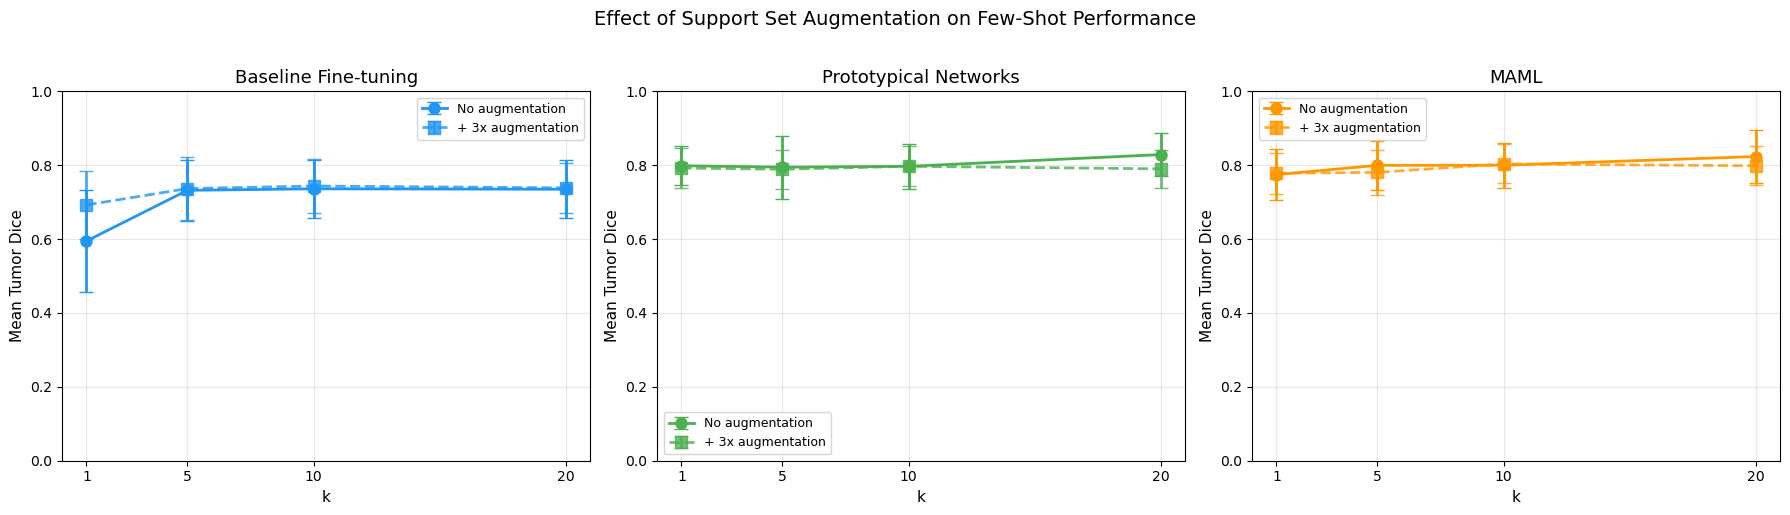

In [8]:
# CELL 8: Comparison Charts — Each Method: Original vs Augmented
k_values = Config.K_SHOT_VALUES
 
methods = [
    ('Baseline Fine-tuning', baseline_orig, baseline_aug_results, '#2196F3'),
    ('Prototypical Networks', proto_orig, proto_aug_results, '#4CAF50'),
    ('MAML', maml_orig, maml_aug_results, '#FF9800'),
]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for ax, (name, orig, aug, color) in zip(axes, methods):
    
    if orig is None or not aug:
        ax.set_title(f'{name}\n(results not available)')
        ax.axis('off')
        continue
 
    # Original
    orig_means = [orig[str(k)]['mean'] for k in k_values]
    orig_stds = [orig[str(k)]['std'] for k in k_values]
    ax.errorbar(k_values, orig_means, yerr=orig_stds, marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label='No augmentation',
                linestyle='-')
 
    # Augmented
    aug_means = [aug[k]['mean'] for k in k_values]
    aug_stds = [aug[k]['std'] for k in k_values]
    ax.errorbar(k_values, aug_means, yerr=aug_stds, marker='s', capsize=5,
                linewidth=2, markersize=8, color=color, label=f'+ {AUGMENT_FACTOR}x augmentation',
                linestyle='--', alpha=0.8)
 
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Mean Tumor Dice', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
 
plt.suptitle('Effect of Support Set Augmentation on Few-Shot Performance',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'augmentation_ablation_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# CELL 9: Delta Table — How Much Does Augmentation Help?
print(f"\n{'='*75}")
print("AUGMENTATION EFFECT: Dice Improvement (augmented - original)")
print(f"{'='*75}")
print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
print(f"{'-'*75}")
 
for name, orig, aug in [
    ('Baseline', baseline_orig, baseline_aug_results),
    ('Prototypical', proto_orig, proto_aug_results),
    ('MAML', maml_orig, maml_aug_results),
]:
    if orig is None or not aug:
        continue
    row = f"{name:<25}"
    for k in k_values:
        orig_mean = orig[str(k)]['mean']
        aug_mean = aug[k]['mean']
        delta = aug_mean - orig_mean
        row += f" {delta:+.4f}     "
    print(row)
 
print(f"{'='*75}")
print("Positive = augmentation helped, Negative = augmentation hurt")


AUGMENTATION EFFECT: Dice Improvement (augmented - original)
Method                    k=1          k=5          k=10         k=20        
---------------------------------------------------------------------------
Baseline                  +0.0977      +0.0048      +0.0076      +0.0037     
Prototypical              -0.0064      -0.0058      +0.0001      -0.0387     
MAML                      +0.0037      -0.0189      +0.0034      -0.0250     
Positive = augmentation helped, Negative = augmentation hurt
